# 03 — Revue visuelle des cas d'erreur

Ce notebook affiche les 25 cas de `eval/error_register_template.csv` (les erreurs reelles du prompt `improved v4`) avec l'image, la vérité terrain, la prédiction et la justification donnée par MedGemma.

**Vérité terrain** = la vraie réponse connue (le label du dataset d'origine), par opposition à ce que le modèle a prédit. C'est la référence pour juger si l'IA a eu raison ou tort.

Usage en deux temps :
1. Regarde toutes les images dans les sections FN / FP / UA ci-dessous.
2. Une fois que tu as tout vu, descends à la dernière section ("Saisie des commentaires") pour taper tes commentaires un par un, puis sauvegarder dans le CSV.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path('..').resolve()
df = pd.read_csv(ROOT / 'eval' / 'error_register_template.csv')
df['error_type'].value_counts()

error_type
FN    12
FP    12
UA     1
Name: count, dtype: int64

In [2]:
# affiche une image avec son contexte (verite terrain, prediction, confiance, justification du modele)
def show_case(row):
    img = Image.open(ROOT / row['image_path'])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"case {row['case_id']} — {row['error_type']} ({row['severity']})\nreel: {row['ground_truth']} | predit: {row['prediction']} (conf {row['confidence']})")
    plt.show()

    print('justification du modele :', row['comment'].replace('[A VERIFIER VISUELLEMENT] justification du modele : ', ''))
    print('piste de correction :', row['corrective_action'])
    print()

## Faux negatifs (FN) : anomalie reelle predite normale

Les plus critiques : le modele rate une vraie anomalie.

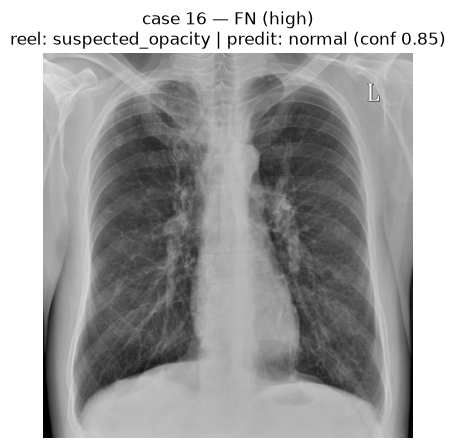

justification du modele : The image shows a frontal chest X-ray with clear lung fields, a normal-sized heart, and a mediastinum that appears unremarkable. There are no obvious signs of pneumonia or other significant lung pathology.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



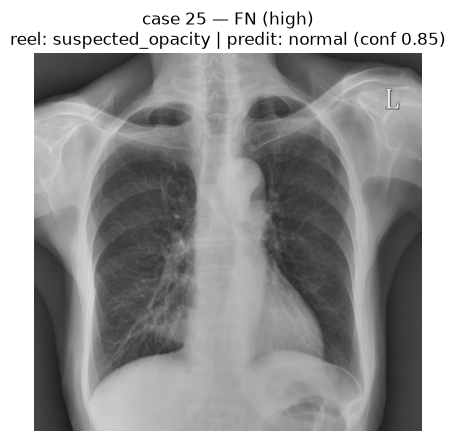

justification du modele : The image shows a clear lung field with no obvious signs of pneumonia or other significant lung pathology. The heart size appears normal. However, without clinical context, it's difficult to definitively rule out subtle abnormalities.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



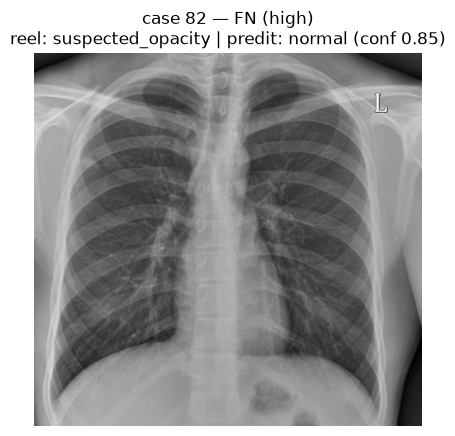

justification du modele : The image shows a clear lung field with no obvious signs of pneumonia or other significant lung pathology. The heart size and mediastinal structures appear normal. The bony structures of the rib cage and clavicles are intact. The image is of good quality.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



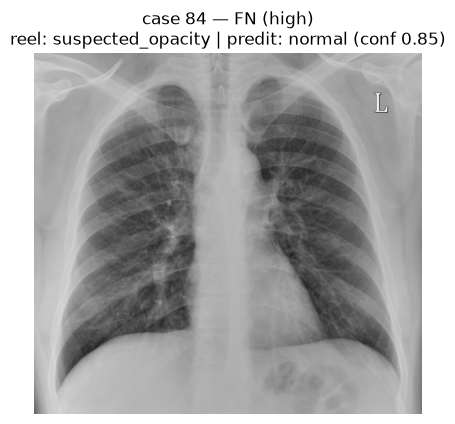

justification du modele : The image shows a frontal chest X-ray with no obvious signs of pneumonia or other significant lung pathology. The lung fields appear clear, and the heart size is normal. However, without clinical information, it's difficult to rule out subtle abnormalities.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



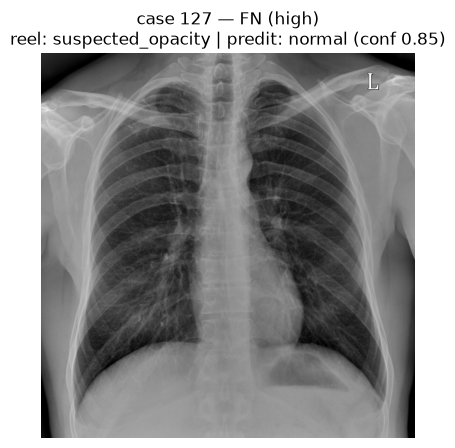

justification du modele : The image shows a clear lung field with no obvious signs of consolidation or infiltrates. The heart size appears normal. The mediastinum is unremarkable. Given the lack of obvious abnormalities, the image is likely normal.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



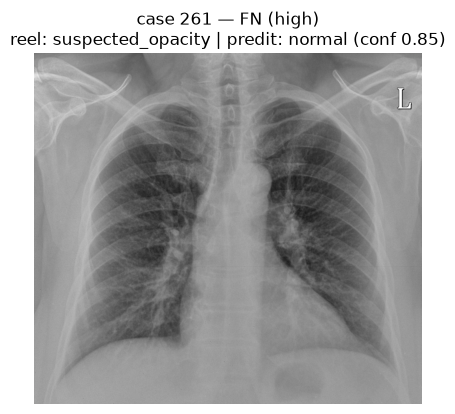

justification du modele : The image shows a frontal chest X-ray with clear lung fields, suggesting no significant abnormalities like pneumonia or consolidation. The heart size appears normal. However, without clinical context, it's difficult to rule out subtle findings.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



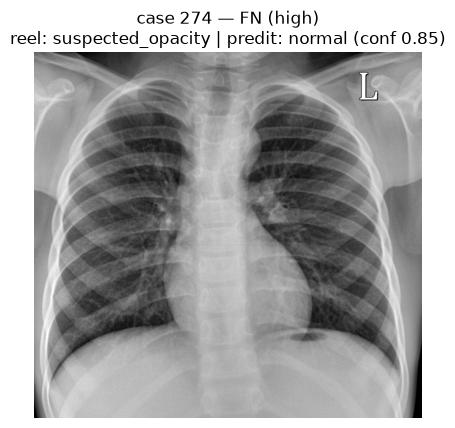

justification du modele : The image shows a frontal chest X-ray with clear lung fields, suggesting no significant abnormalities. The heart size appears normal, and the mediastinum is unremarkable. However, without clinical context, it's difficult to rule out subtle findings.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



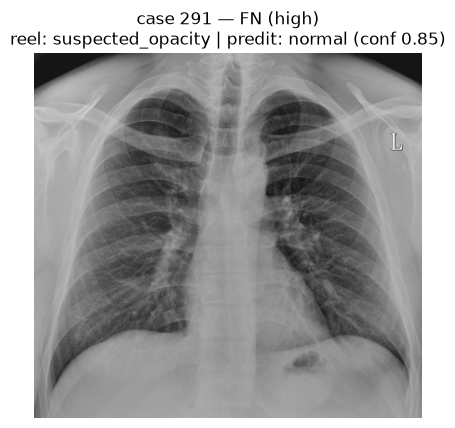

justification du modele : The image shows a frontal chest X-ray with clear lung fields, suggesting no significant abnormalities. The heart size appears normal, and the mediastinum is unremarkable. However, without clinical context, it's difficult to rule out subtle findings.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



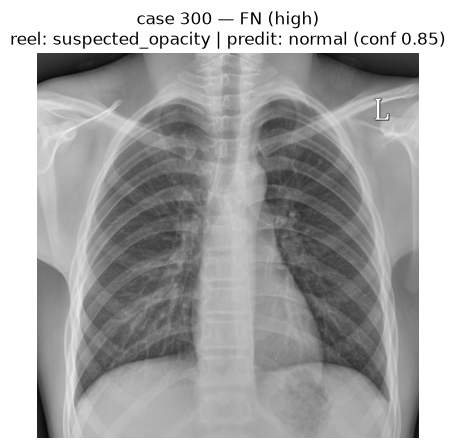

justification du modele : The image shows a clear lung field with no obvious signs of pneumonia or other significant lung pathology. The heart size and mediastinal structures appear normal. The bony structures are intact. The image is of good quality.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



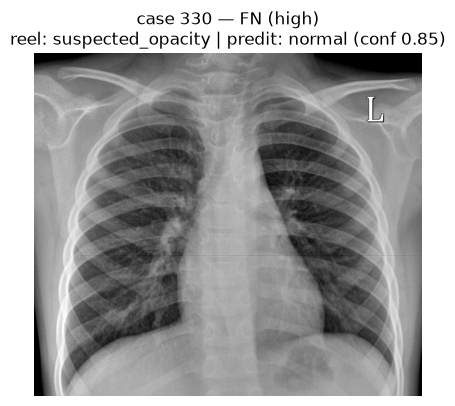

justification du modele : The image shows a frontal chest X-ray with clear lung fields, suggesting no significant abnormalities. The heart size appears normal, and the mediastinum is unremarkable. However, without clinical context, it's difficult to rule out subtle findings.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



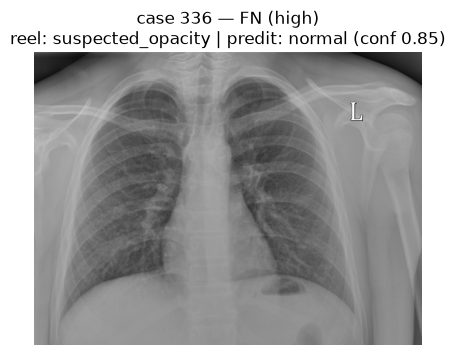

justification du modele : The image shows a frontal chest X-ray with no obvious signs of pneumonia or other significant lung pathology. The lung fields appear clear, and the heart size is normal. However, the image quality is good, and the clinical context is missing.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



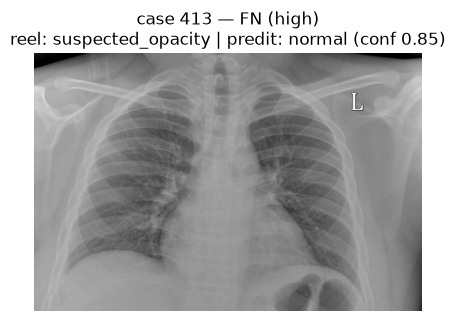

justification du modele : The image shows a frontal chest X-ray with clear lung fields, suggesting no significant abnormalities. The heart size appears normal, and the mediastinum is unremarkable. However, without clinical context, it's difficult to definitively rule out subtle findings.
piste de correction : revoir le prompt / seuil de confiance pour mieux detecter les opacites subtiles



In [3]:
for _, row in df[df['error_type'] == 'FN'].iterrows():
    show_case(row)

## Faux positifs (FP) : poumon normal predit suspect

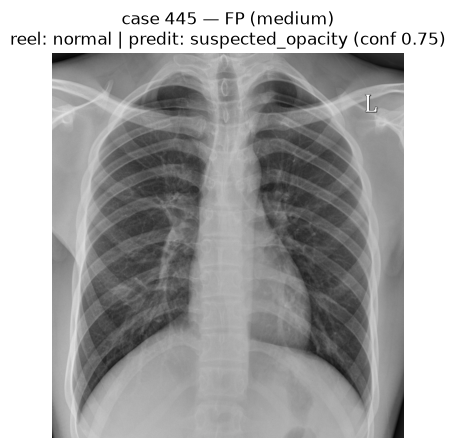

justification du modele : The hazy opacity in the right lower lung field could be a sign of consolidation, which can be associated with pneumonia. However, it could also be a normal anatomical variation or other less serious condition. Further investigation is needed to determine the cause.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



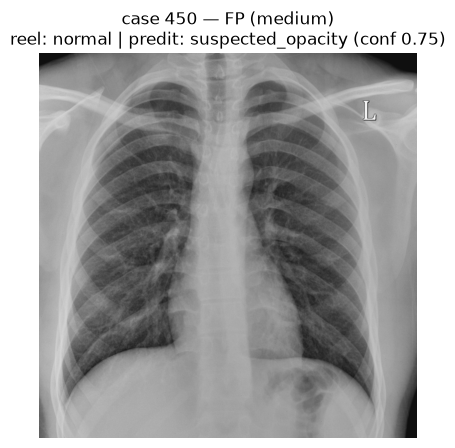

justification du modele : The hazy opacity in the right lower lung field could be a sign of consolidation, which is often associated with pneumonia. However, it could also be a normal anatomical variation or other less serious condition. Further investigation is needed to determine the cause.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



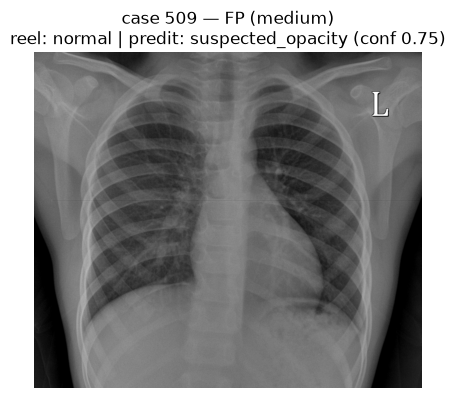

justification du modele : The image shows a possible area of increased density in the lower lung fields, which could be consistent with pneumonia or other lung opacities. The subtle haziness in the right lower lung field is also a possible finding.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



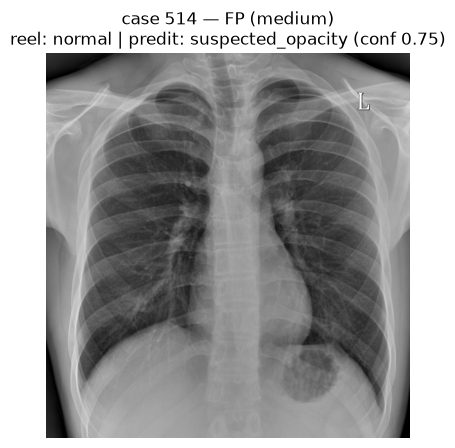

justification du modele : The hazy opacity in the right lower lung field is the most prominent finding. While it could be a normal variant, it warrants further investigation to rule out a potential pneumonia or other lung pathology. The heart size appears normal, and the mediastinum is unremarkable, which is a positive finding.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



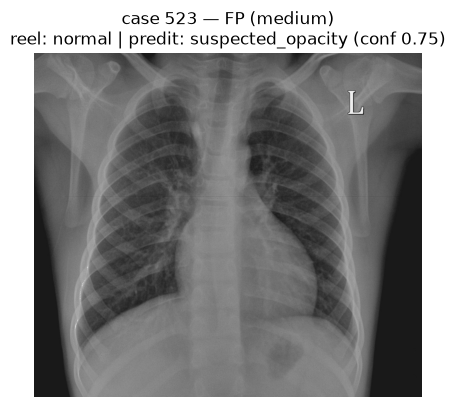

justification du modele : There is a possible opacity in the right lung field. The opacity in the left lung field is less clear. The image quality is good, but the lack of clinical context makes it difficult to determine the cause of the opacity.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



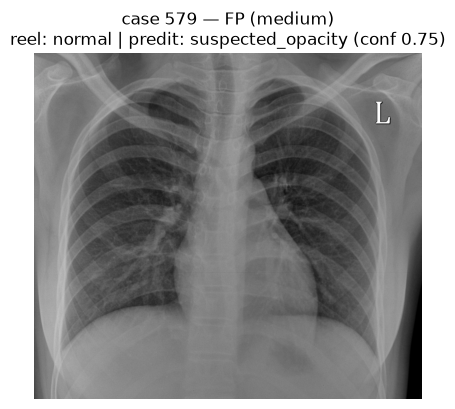

justification du modele : There is a possible opacity in the right lower lung field. The opacity in the left lower lung field is less clear. The image quality is good, allowing for a reasonable assessment.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



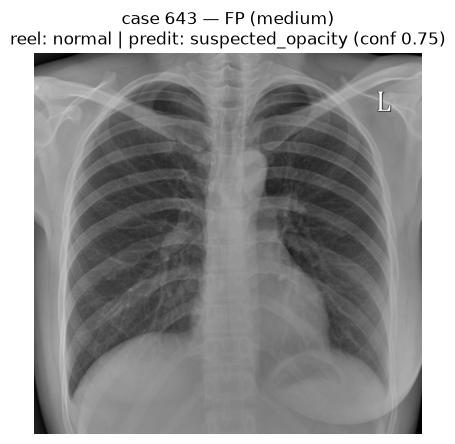

justification du modele : The hazy opacity in the right lower lung field could be a sign of consolidation, which can be associated with pneumonia or other lung infections. The heart size appears normal, and the mediastinum is midline, which are both reassuring findings. However, further investigation is needed to determine the cause of the opacity.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



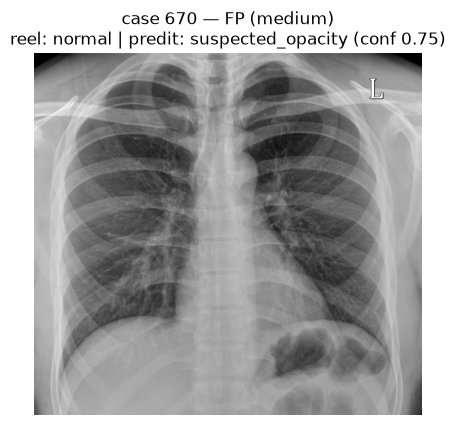

justification du modele : The hazy opacity in the right lower lung field could be a sign of consolidation, which can be associated with pneumonia. However, it is difficult to determine the exact cause without further information.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



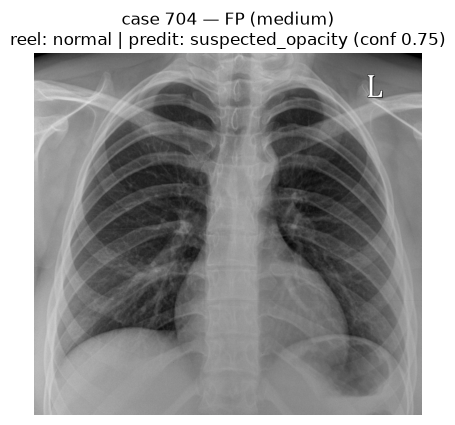

justification du modele : The hazy opacity in the right lower lung field could be a sign of consolidation, potentially related to pneumonia or other lung infection. The heart size appears normal, and the mediastinum is unremarkable. However, without clinical context, it's difficult to determine the exact cause.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



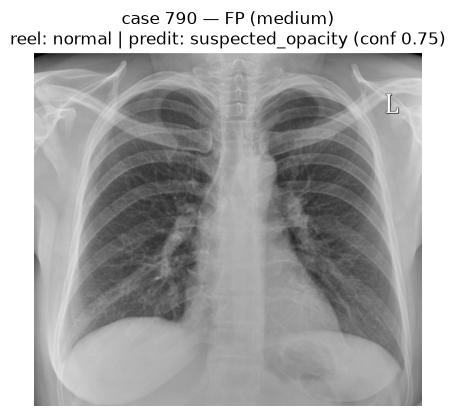

justification du modele : There are some areas of increased density in the lower lung fields, which could represent consolidation due to pneumonia or other infiltrative processes. The exact nature of these densities cannot be determined from this single image.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



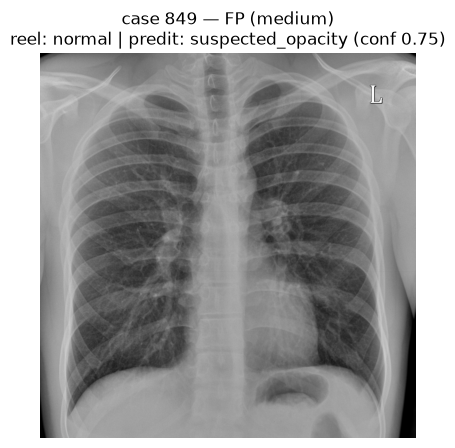

justification du modele : The image shows a possible opacity in the lower lung fields. This could be due to consolidation, fluid, or other abnormalities. Further evaluation is needed to determine the cause.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



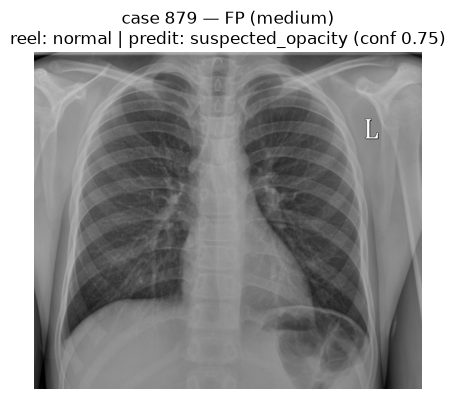

justification du modele : The hazy opacity in the right lower lung field could be a sign of consolidation, which can be associated with pneumonia. However, it is difficult to determine the exact cause without further information.
piste de correction : revoir le prompt pour reduire les faux positifs sur poumons normaux



In [4]:
for _, row in df[df['error_type'] == 'FP'].iterrows():
    show_case(row)

## Incertitude acceptable (UA) : repli sur uncertain

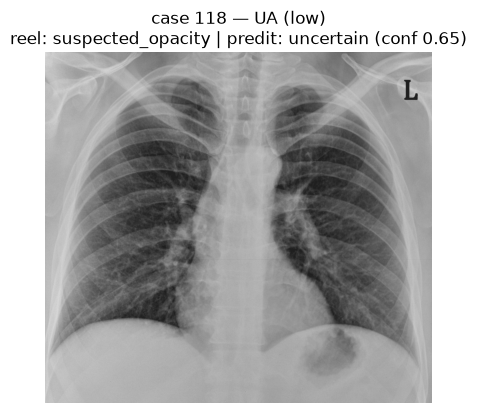

justification du modele : The image shows a frontal chest X-ray. While the lungs appear clear, there are no definitive signs of pneumonia or other significant lung pathology. Further information is needed to make a more accurate assessment.
piste de correction : repli sur incertain juge acceptable, garder la regle telle quelle



In [5]:
for _, row in df[df['error_type'] == 'UA'].iterrows():
    show_case(row)

## Saisie des commentaires

Une fois que tu as regardé toutes les images ci-dessus, exécute la cellule suivante. Elle te demande, cas par cas, ton commentaire et ta piste de correction.

Laisser vide (Entrée directe) = garde la valeur actuelle sans la changer. Utile si tu veux ne modifier que certains cas.

In [ ]:
# pour chaque cas, demande un commentaire et une piste de correction
# laisser vide = garde la valeur actuelle
for idx, row in df.iterrows():
    print(f"case {row['case_id']} — {row['error_type']} | reel: {row['ground_truth']} predit: {row['prediction']}")

    new_comment = input('Ton commentaire (Entree pour ne pas changer) : ')
    if new_comment.strip():
        df.at[idx, 'comment'] = new_comment

    new_action = input('Piste de correction (Entree pour ne pas changer) : ')
    if new_action.strip():
        df.at[idx, 'corrective_action'] = new_action

    print()

In [ ]:
# sauvegarde dans le vrai fichier, une fois que tu es content des commentaires
df.to_csv(ROOT / 'eval' / 'error_register_template.csv', index=False)
print('sauvegarde faite')